In [175]:
from typing import TypedDict, List, Dict
from langgraph.graph import StateGraph, START, END
import random

In [176]:
class GameState(TypedDict):
    player_name: str
    target_number: int
    guess_number: List[int]
    attempts: int
    hint: str
    lower_bound: int
    upper_bound: int

In [179]:
def setup_node(state: GameState) -> GameState:
    state['target_number'] = random.randint(1, 20)
    state['attempts'] = 0
    state['hint'] = "Game Started! Try To Guess Number"
    state['guess_number'] = []
    state['player_name'] = f"Welcome, {state['player_name']}"
    state['lower_bound'] = 1
    state['upper_bound'] = 20

    print(f"{state['player_name']} The Game Started. I'm thinking of a number between 1 and 20")

    return state


In [180]:
def guess_node(state: GameState) -> GameState:
    possible_guess = [
        i for i in range(state['lower_bound'], state['upper_bound'] + 1)
        if i not in state['guess_number']
    ]

    if possible_guess:
        guess = random.choice(possible_guess)
    else:
        guess = random.randint(state['lower_bound'], state['upper_bound'])

    state['guess_number'].append(guess)
    state["attempts"] += 1

    print(f"Attempt {state['attempts']}: Guessing: {guess}")

    return state

    

In [181]:

def hints_node(state: GameState) -> GameState:
    latest_number = state['guess_number'][-1]
    target = state["target_number"]

    if latest_number > target:
        state["hint"] = f"The number {latest_number} is too high. Try lower!"
        print(f"Hint: {state['hint']}")

    elif latest_number < target:
        state["hint"] = f"The number {latest_number} is too low. Try higher!"
        print(f"Hint: {state['hint']}")

    else:
        state["hint"] = f"Correct! You found the number {target} in {state['attempts']} attempts."
        print(state["hint"])

    return state

In [182]:
def should_continue(state: GameState) -> str:
    latest_number = state['guess_number'][-1]
    target = state["target_number"]

    if latest_number == target:
        print("Game Over: Number Found!")
        return "end"

    elif state['attempts'] >= 7:
        print(f"Game Over: Attempts reached! The Number was {target}")
        return "end"

    else:
        print(f"Continue: {state['attempts']}/7 attempts used")
        return "continue"

    
     
    
    

In [183]:
graph = StateGraph(GameState)

graph.add_node('setup_node', setup_node)
graph.add_node('guess_node', guess_node)
graph.add_node('hints_node', hints_node)

graph.add_edge('setup_node', 'guess_node')
graph.add_edge('guess_node', 'hints_node')

graph.add_conditional_edges(
    "hints_node",
    should_continue,
    {
        "continue": "guess_node",
        "end": END
    }
)

graph.set_entry_point('setup_node')

app = graph.compile()




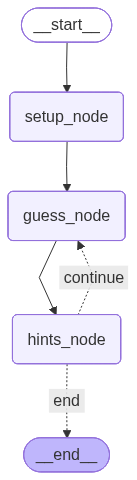

In [184]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [185]:
result = app.invoke({
    "player_name": "Masud",
    "guess_number": [],
    "attempts": 0,
    "lower_bound": 1,
    "upper_bound": 20
})

Welcome, Masud The Game Started. I'm thinking of a number between 1 and 20
Attempt 1: Guessing: 3
Hint: The number 3 is too low. Try higher!
Continue: 1/7 attempts used
Attempt 2: Guessing: 9
Hint: The number 9 is too low. Try higher!
Continue: 2/7 attempts used
Attempt 3: Guessing: 16
Hint: The number 16 is too low. Try higher!
Continue: 3/7 attempts used
Attempt 4: Guessing: 6
Hint: The number 6 is too low. Try higher!
Continue: 4/7 attempts used
Attempt 5: Guessing: 8
Hint: The number 8 is too low. Try higher!
Continue: 5/7 attempts used
Attempt 6: Guessing: 11
Hint: The number 11 is too low. Try higher!
Continue: 6/7 attempts used
Attempt 7: Guessing: 20
Hint: The number 20 is too high. Try lower!
Game Over: Attempts reached! The Number was 19
